<a href="https://colab.research.google.com/github/srilakshmi-saladi/unet/blob/main/brisc2025_multitask_segmentation_classification_91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BRISC2025 Brain Tumor MRI — Multi-Task Segmentation + Classification

This notebook is designed for the **BRISC2025** dataset structure in Google Drive.

## What this notebook does
- Uses **segmentation_task** images and masks
- Derives classification labels from BRISC filename codes:
  - `gl` = glioma
  - `me` = meningioma
  - `pi` = pituitary
  - `nt` = no tumor
- Trains a **multi-task U-Net style model**
  - Segmentation output
  - Classification output
- Reports:
  - **Classification:** Accuracy, Precision, Recall, Macro F1, QWK
  - **Segmentation:** Dice, IoU

## Important note
This is a **best-effort paper-inspired setup** based on BRISC and a public BRISC Colab-style implementation. It is suitable for Colab and aims to give you both segmentation and classification metrics from the same training run, but it does **not guarantee 90%+ classification accuracy**.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 114.9 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [5]:
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def cleanup_memory():
    gc.collect()
    tf.keras.backend.clear_session()

print("TensorFlow version:", tf.__version__)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0


In [6]:
# ============================================
# CONFIG — AUTO-DETECT BRISC FOLDER
# ============================================
BASE_CANDIDATES = [
    "/content/drive/MyDrive/brain dataset/brisc2025",
    "/content/drive/MyDrive/brain_dataset/brisc2025",
    "/content/drive/MyDrive/brain dataset/BRISC2025",
]

BASE_DIR = None
for p in BASE_CANDIDATES:
    if (
        os.path.exists(os.path.join(p, "segmentation_task")) and
        os.path.exists(os.path.join(p, "classification_task"))
    ):
        BASE_DIR = p
        break

assert BASE_DIR is not None, "Could not find BRISC2025 folder. Update BASE_CANDIDATES if needed."

SEG_TRAIN_IMG_DIR = os.path.join(BASE_DIR, "segmentation_task", "train", "images")
SEG_TRAIN_MSK_DIR = os.path.join(BASE_DIR, "segmentation_task", "train", "masks")
SEG_TEST_IMG_DIR  = os.path.join(BASE_DIR, "segmentation_task", "test", "images")
SEG_TEST_MSK_DIR  = os.path.join(BASE_DIR, "segmentation_task", "test", "masks")

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 30

SAVE_DIR = os.path.join(BASE_DIR, "multitask_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

print("Using BASE_DIR:", BASE_DIR)
print("Train images:", SEG_TRAIN_IMG_DIR)
print("Train masks :", SEG_TRAIN_MSK_DIR)
print("Test images :", SEG_TEST_IMG_DIR)
print("Test masks  :", SEG_TEST_MSK_DIR)
print("SAVE_DIR    :", SAVE_DIR)

Using BASE_DIR: /content/drive/MyDrive/brain dataset/brisc2025
Train images: /content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/train/images
Train masks : /content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/train/masks
Test images : /content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/test/images
Test masks  : /content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/test/masks
SAVE_DIR    : /content/drive/MyDrive/brain dataset/brisc2025/multitask_outputs


In [7]:
# ============================================
# VERIFY DATASET
# ============================================
required_paths = [
    SEG_TRAIN_IMG_DIR, SEG_TRAIN_MSK_DIR,
    SEG_TEST_IMG_DIR, SEG_TEST_MSK_DIR
]

for p in required_paths:
    print(p, "->", os.path.exists(p))

assert all(os.path.exists(p) for p in required_paths), "Missing segmentation task folders"

train_images = sorted([f for f in os.listdir(SEG_TRAIN_IMG_DIR) if f.lower().endswith(".jpg")])
train_masks  = sorted([f for f in os.listdir(SEG_TRAIN_MSK_DIR) if f.lower().endswith(".png")])
test_images  = sorted([f for f in os.listdir(SEG_TEST_IMG_DIR) if f.lower().endswith(".jpg")])
test_masks   = sorted([f for f in os.listdir(SEG_TEST_MSK_DIR) if f.lower().endswith(".png")])

print("Train images:", len(train_images))
print("Train masks :", len(train_masks))
print("Test images :", len(test_images))
print("Test masks  :", len(test_masks))

/content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/train/images -> True
/content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/train/masks -> True
/content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/test/images -> True
/content/drive/MyDrive/brain dataset/brisc2025/segmentation_task/test/masks -> True
Train images: 3933
Train masks : 3933
Test images : 860
Test masks  : 860


In [8]:
# ============================================
# BUILD DATAFRAME FROM SEGMENTATION TASK
# ============================================
CLASS_MAP = {
    "gl": 0,
    "me": 1,
    "pi": 2,
    "nt": 3
}

def extract_label_code(filename):
    parts = filename.split("_")
    for p in parts:
        if p in CLASS_MAP:
            return p
    raise ValueError(f"Could not extract class code from {filename}")

def build_pairs(img_dir, mask_dir):
    rows = []
    for img_name in sorted(os.listdir(img_dir)):
        if not img_name.lower().endswith(".jpg"):
            continue
        mask_name = img_name.replace(".jpg", ".png")
        img_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)
        if os.path.exists(mask_path):
            code = extract_label_code(img_name)
            rows.append({
                "image_path": img_path,
                "mask_path": mask_path,
                "filename": img_name,
                "label_code": code,
                "label": CLASS_MAP[code]
            })
    return pd.DataFrame(rows)

train_df_full = build_pairs(SEG_TRAIN_IMG_DIR, SEG_TRAIN_MSK_DIR)
test_df = build_pairs(SEG_TEST_IMG_DIR, SEG_TEST_MSK_DIR)

print("Train full shape:", train_df_full.shape)
print("Test shape:", test_df.shape)

display(train_df_full["label_code"].value_counts())
display(test_df["label_code"].value_counts())

Train full shape: (3933, 5)
Test shape: (860, 5)


,count
label_code,
pi,1457
me,1329
gl,1147


,count
label_code,
me,306
pi,300
gl,254


In [9]:
# ============================================
# TRAIN/VAL SPLIT
# ============================================
train_df, val_df = train_test_split(
    train_df_full,
    test_size=0.10,
    stratify=train_df_full["label"],
    random_state=SEED
)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (3539, 5)
Val  : (394, 5)
Test : (860, 5)


In [10]:
# ============================================
# IMAGE + MASK LOADING
# ============================================
def read_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def read_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return mask

def preprocess_record(image_path, mask_path, label, training=False):
    image = read_image(image_path)
    mask = read_mask(mask_path)

    if training:
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)
            mask = tf.image.flip_left_right(mask)
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_up_down(image)
            mask = tf.image.flip_up_down(mask)

    return image, {
        "seg_output": mask,
        "cls_output": tf.cast(label, tf.int32)
    }

def make_dataset(df_in, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df_in["image_path"].values,
        df_in["mask_path"].values,
        df_in["label"].values
    ))
    ds = ds.map(lambda x, y, z: preprocess_record(x, y, z, training=training),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1024, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

print("Datasets ready.")

Datasets ready.


In [11]:
# ============================================
# METRICS
# ============================================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [12]:
# ============================================
# MODEL — LIGHTWEIGHT MULTI-TASK U-NET
# ============================================
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_multitask_unet(input_shape=(128, 128, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    bn = conv_block(p3, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(bn)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, 32)

    seg_output = layers.Conv2D(1, 1, activation="sigmoid", name="seg_output")(c6)

    x = layers.GlobalAveragePooling2D()(bn)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    cls_output = layers.Dense(num_classes, activation="softmax", name="cls_output")(x)

    model = Model(inputs=inputs, outputs=[seg_output, cls_output])
    return model

cleanup_memory()
model = build_multitask_unet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=4)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 1,972,645 (7.53 MB)

 Trainable params: 1,969,829 (7.51 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "seg_output": tf.keras.losses.BinaryCrossentropy(),
        "cls_output": tf.keras.losses.SparseCategoricalCrossentropy(),
    },
    loss_weights={
        "seg_output": 1.0,
        "cls_output": 1.0,
    },
    metrics={
        "seg_output": [dice_coef, iou_coef],
        "cls_output": ["accuracy"]
    }
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "best_multitask_unet.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(os.path.join(SAVE_DIR, "training_log.csv"))
]

In [14]:
# ============================================
# TRAIN
# ============================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - cls_output_accuracy: 0.6404 - cls_output_loss: 0.8533 - loss: 1.0782 - seg_output_dice_coef: 0.0687 - seg_output_iou_coef: 0.0380 - seg_output_loss: 0.2249
Epoch 1: val_loss improved from None to 7.64411, saving model to /content/drive/MyDrive/brain dataset/brisc2025/multitask_outputs/best_multitask_unet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain dataset/brisc2025/multitask_outputs/best_multitask_unet.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 135s 338ms/step - cls_output_accuracy: 0.6807 - cls_output_loss: 0.7658 - loss: 0.9017 - seg_output_dice_coef: 0.0709 - seg_output_iou_coef: 0.0393 - seg_output_loss: 0.1341 - val_cls_output_accuracy: 0.2919 - val_cls_output_loss: 7.5424 - val_loss: 7.6441 - val_seg_output_dice_coef: 2.4206e-10 - val_seg_output_iou_coef: 2.4206e-10 - val_seg_output_loss: 0.1353 - learning_rate: 0.0010
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - cls_output_accuracy: 0.7749 - cls

In [15]:
# ============================================
# LOAD BEST MODEL
# ============================================
best_model = tf.keras.models.load_model(
    os.path.join(SAVE_DIR, "best_multitask_unet.keras"),
    custom_objects={
        "dice_coef": dice_coef,
        "iou_coef": iou_coef
    }
)
print("Best model loaded.")

Best model loaded.


In [16]:
# ============================================
# TEST EVALUATION
# ============================================
test_results = best_model.evaluate(test_ds, verbose=1)
print("Raw test results:", test_results)

54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 396ms/step - cls_output_accuracy: 0.9140 - cls_output_loss: 0.2374 - loss: 0.2691 - seg_output_dice_coef: 0.6705 - seg_output_iou_coef: 0.5428 - seg_output_loss: 0.0306
Raw test results: [0.26910871267318726, 0.030601944774389267, 0.23742657899856567, 0.9139534831047058, 0.6705397367477417, 0.5428274273872375]


In [17]:
# ============================================
# GET PREDICTIONS
# ============================================
y_true_cls = []
y_pred_cls = []
dice_scores = []
iou_scores = []

for images, targets in test_ds:
    seg_true = targets["seg_output"]
    cls_true = targets["cls_output"]

    seg_pred, cls_pred = best_model.predict(images, verbose=0)
    cls_pred_labels = np.argmax(cls_pred, axis=1)

    y_true_cls.extend(cls_true.numpy().tolist())
    y_pred_cls.extend(cls_pred_labels.tolist())

    for i in range(len(images)):
        d = dice_coef(seg_true[i], seg_pred[i]).numpy()
        j = iou_coef(seg_true[i], seg_pred[i]).numpy()
        dice_scores.append(float(d))
        iou_scores.append(float(j))

y_true_cls = np.array(y_true_cls)
y_pred_cls = np.array(y_pred_cls)

acc = accuracy_score(y_true_cls, y_pred_cls)
precision = precision_score(y_true_cls, y_pred_cls, average="macro", zero_division=0)
recall = recall_score(y_true_cls, y_pred_cls, average="macro", zero_division=0)
f1 = f1_score(y_true_cls, y_pred_cls, average="macro", zero_division=0)
qwk = cohen_kappa_score(y_true_cls, y_pred_cls, weights="quadratic")
mean_dice = float(np.mean(dice_scores))
mean_iou = float(np.mean(iou_scores))

print("Classification Accuracy:", acc)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1:", f1)
print("QWK:", qwk)
print("Mean Dice:", mean_dice)
print("Mean IoU:", mean_iou)

Classification Accuracy: 0.913953488372093
Macro Precision: 0.9233572100560442
Macro Recall: 0.9086200744514779
Macro F1: 0.9121881725969136
QWK: 0.917031609070806
Mean Dice: 0.6387973185734086
Mean IoU: 0.5560786844599235


              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       254
  meningioma       0.86      0.92      0.89       306
   pituitary       0.92      0.99      0.95       300

    accuracy                           0.91       860
   macro avg       0.92      0.91      0.91       860
weighted avg       0.92      0.91      0.91       860



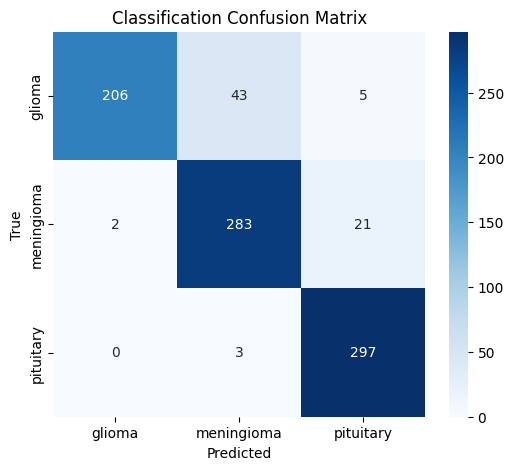

In [18]:
# ============================================
# REPORTS
# ============================================
full_target_names = ["glioma", "meningioma", "pituitary", "no_tumor"]

# Get unique labels present in the true values
unique_labels_in_data = np.unique(y_true_cls)

# Create a new list of target names based on the unique labels
actual_target_names = [full_target_names[i] for i in unique_labels_in_data]

print(classification_report(y_true_cls, y_pred_cls, labels=unique_labels_in_data, target_names=actual_target_names, zero_division=0))

cm = confusion_matrix(y_true_cls, y_pred_cls, labels=unique_labels_in_data)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=actual_target_names, yticklabels=actual_target_names)
plt.title("Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [19]:
# ============================================
# SAVE FINAL METRICS
# ============================================
final_metrics = pd.DataFrame([{
    "Model": "BRISC_MultiTask_UNet",
    "Classification Accuracy": acc,
    "Macro Precision": precision,
    "Macro Recall": recall,
    "Macro F1": f1,
    "QWK": qwk,
    "Mean Dice": mean_dice,
    "Mean IoU": mean_iou,
    "Saved Model": os.path.join(SAVE_DIR, "best_multitask_unet.keras")
}])

display(final_metrics)

metrics_csv = os.path.join(SAVE_DIR, "final_metrics.csv")
final_metrics.to_csv(metrics_csv, index=False)
print("Saved metrics to:", metrics_csv)

,Model,Classification Accuracy,Macro Precision,Macro Recall,Macro F1,QWK,Mean Dice,Mean IoU,Saved Model
0,BRISC_MultiTask_UNet,0.913953,0.923357,0.90862,0.912188,0.917032,0.638797,0.556079,/content/drive/MyDrive/brain dataset/brisc2025...


Saved metrics to: /content/drive/MyDrive/brain dataset/brisc2025/multitask_outputs/final_metrics.csv
